In [ ]:
from google.colab import drive

drive.mount('/content/drive')


DATASET_CSV = "/content/drive/MyDrive/datasets/fer2013.csv"

BASE_OUTPUT_DIR = "/content/data_fer2013"
print("Using CSV:", DATASET_CSV)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using CSV: /content/drive/MyDrive/datasets/fer2013.csv


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# Load FER2013 CSV from Drive
df = pd.read_csv(DATASET_CSV)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Usage values:", df["Usage"].unique())
df.head()

Shape: (35887, 3)
Columns: ['emotion', 'pixels', 'Usage']
Usage values: ['Training' 'PublicTest' 'PrivateTest']


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [ ]:
# FER2013 labels: 0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral
emotion_id_to_name = {
    0: "angry",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral",
}

df["emotion_name"] = df["emotion"].map(emotion_id_to_name)

# Split according to Usage
train_df = df[df["Usage"] == "Training"].reset_index(drop=True)
val_df   = df[df["Usage"] == "PublicTest"].reset_index(drop=True)
test_df  = df[df["Usage"] == "PrivateTest"].reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

Train size: 28709
Val size: 3589
Test size: 3589


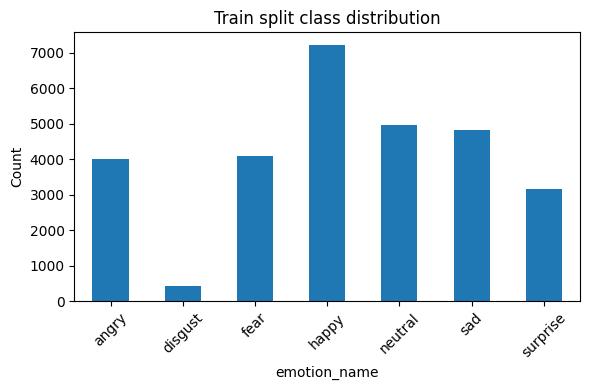

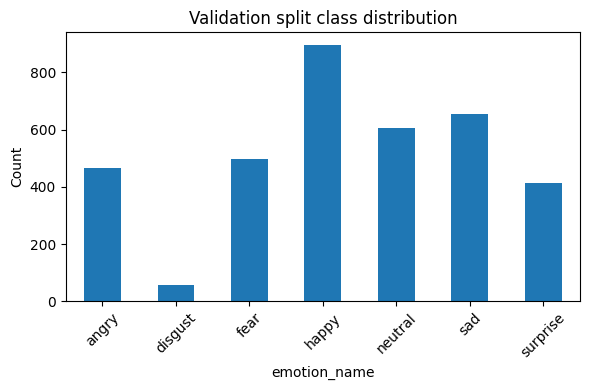

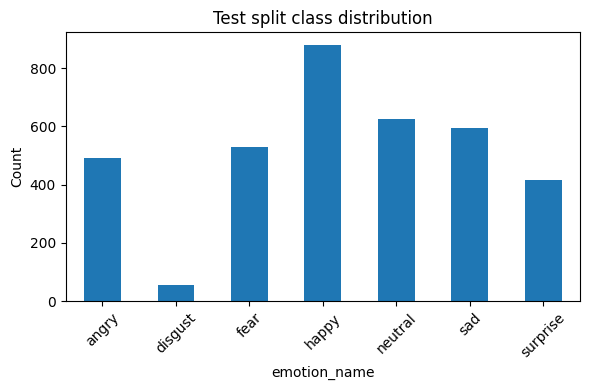

In [ ]:
def plot_split_distribution(df, title):
    counts = df["emotion_name"].value_counts().sort_index()
    plt.figure(figsize=(6,4))
    counts.plot(kind="bar")
    plt.ylabel("Count")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_split_distribution(train_df, "Train split class distribution")
plot_split_distribution(val_df, "Validation split class distribution")
plot_split_distribution(test_df, "Test split class distribution")

In [ ]:
def pixels_to_array(pixels_str):
    arr = np.fromstring(pixels_str, dtype=np.uint8, sep=" ")
    return arr.reshape(48, 48)

def build_xy(df_split):
    X_list = []
    y_list = []
    for _, row in df_split.iterrows():
        img = pixels_to_array(row["pixels"])
        X_list.append(img)
        y_list.append(int(row["emotion"]))
    X = np.stack(X_list, axis=0)  # (N, 48, 48)
    y = np.array(y_list, dtype=np.int64)
    return X, y

X_train, y_train = build_xy(train_df)
X_val,   y_val   = build_xy(val_df)
X_test,  y_test  = build_xy(test_df)

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_val shape:",   X_val.shape,   "y_val shape:",   y_val.shape)
print("X_test shape:",  X_test.shape,  "y_test shape:",  y_test.shape)

X_train shape: (28709, 48, 48) y_train shape: (28709,)
X_val shape: (3589, 48, 48) y_val shape: (3589,)
X_test shape: (3589, 48, 48) y_test shape: (3589,)


In [ ]:
# Normalise to [0,1] and add channel dimension
X_train = X_train.astype("float32") / 255.0
X_val   = X_val.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, axis=-1)  # (N, 48, 48, 1)
X_val   = np.expand_dims(X_val, axis=-1)
X_test  = np.expand_dims(X_test, axis=-1)

# One-hot encoding the labels
num_classes = len(emotion_id_to_name)
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

print("After preprocessing:")
print("X_train:", X_train.shape, "y_train_cat:", y_train_cat.shape)

After preprocessing:
X_train: (28709, 48, 48, 1) y_train_cat: (28709, 7)


In [ ]:
from tensorflow.keras import layers, models

def residual_block(x, filters, kernel_size=3):
    shortcut = x
    x = layers.Conv2D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # If channel dimensions differ, project shortcut
    if shortcut.shape[-1] != x.shape[-1]:
        shortcut = layers.Conv2D(filters, 1, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

input_layer = layers.Input(shape=(48, 48, 1))

x = layers.Conv2D(32, 3, padding="same", use_bias=False)(input_layer)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)  # 24x24

x = residual_block(x, 32)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)  # 12x12

x = residual_block(x, 64)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)  # 6x6

x = residual_block(x, 128)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
output_layer = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs=input_layer, outputs=output_layer)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 48,    │        288 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 48,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 24, 24,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 24, 24,    │      9,216 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 24, 24,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 24, 24,    │      9,216 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 24,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 24, 24,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 12, 12,    │          0 │ re_lu_2[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 12, 12,    │     18,432 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 12,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 12, 12,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 12, 12,    │     36,864 │ re_lu_3[0][0]   

 Total params: 309,031 (1.18 MB)

 Trainable params: 307,687 (1.17 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight = {i: class_weights_array[i] for i in range(num_classes)}
print("Class weights:", class_weight)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        "/content/best_resnet_fer2013.h5",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=60,
    batch_size=128,
    class_weight=class_weight,
    verbose=1,
    callbacks=callbacks,
)

Class weights: {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8491274770777877), 5: np.float64(1.293372978330405), 6: np.float64(0.8260394187886635)}
Epoch 1/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2099 - loss: 2.0188
Epoch 1: val_loss improved from inf to 2.50158, saving model to /content/best_resnet_fer2013.h5


225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - accuracy: 0.2102 - loss: 2.0181 - val_accuracy: 0.0156 - val_loss: 2.5016
Epoch 2/60
223/225 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3850 - loss: 1.5874
Epoch 2: val_loss improved from 2.50158 to 2.04137, saving model to /content/best_resnet_fer2013.h5


225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.3853 - loss: 1.5869 - val_accuracy: 0.2009 - val_loss: 2.0414
Epoch 3/60
224/225 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4583 - loss: 1.3848
Epoch 3: val_loss improved from 2.04137 to 1.45112, saving model to /content/best_resnet_fer2013.h5


225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4584 - loss: 1.3846 - val_accuracy: 0.4714 - val_loss: 1.4511
Epoch 4/60
224/225 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4986 - loss: 1.2735
Epoch 4: val_loss did not improve from 1.45112
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4987 - loss: 1.2734 - val_accuracy: 0.3252 - val_loss: 2.1818
Epoch 5/60
223/225 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5375 - loss: 1.1586
Epoch 5: val_loss did not improve from 1.45112
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5375 - loss: 1.1587 - val_accuracy: 0.3697 - val_loss: 2.2844
Epoch 6/60
222/225 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5564 - loss: 1.0961
Epoch 6: val_loss did not improve from 1.45112
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5564 - loss: 1.0961 - val_accuracy: 0.4071 - val_loss: 1.5555
Epoch 7/60
223/225 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5799 - loss: 1.0368
Epoch 7: val_loss did not improve from 

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6423 - loss: 0.8698 - val_accuracy: 0.4684 - val_loss: 1.4332
Epoch 10/60
222/225 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6509 - loss: 0.8571
Epoch 10: val_loss improved from 1.43317 to 1.31905, saving model to /content/best_resnet_fer2013.h5


225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6509 - loss: 0.8571 - val_accuracy: 0.5035 - val_loss: 1.3190
Epoch 11/60
223/225 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6741 - loss: 0.7843
Epoch 11: val_loss did not improve from 1.31905
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6740 - loss: 0.7847 - val_accuracy: 0.2784 - val_loss: 3.0919
Epoch 12/60
222/225 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6815 - loss: 0.7738
Epoch 12: val_loss did not improve from 1.31905
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6816 - loss: 0.7735 - val_accuracy: 0.3709 - val_loss: 1.9568
Epoch 13/60
224/225 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7172 - loss: 0.6760
Epoch 13: val_loss did not improve from 1.31905
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7172 - loss: 0.6762 - val_accuracy: 0.5249 - val_loss: 1.4418
Epoch 14/60
223/225 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7287 - loss: 0.6629
Epoch 14: val_loss did not impro

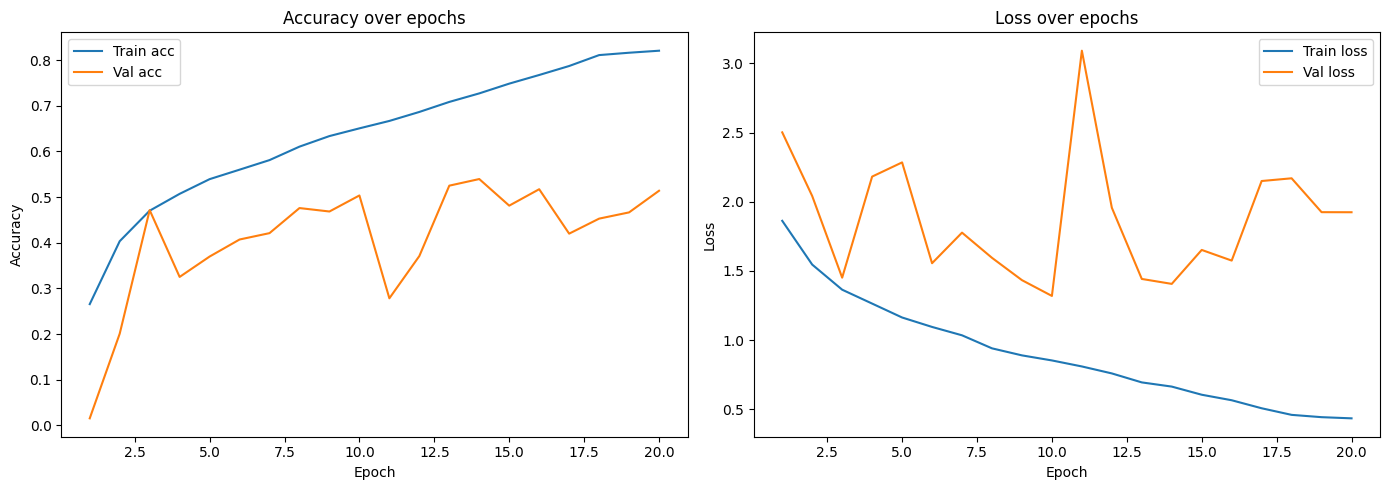

In [ ]:
def plot_history(hist):
    epochs_range = range(1, len(hist.history["accuracy"]) + 1)
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axs[0].plot(epochs_range, hist.history["accuracy"], label="Train acc")
    axs[0].plot(epochs_range, hist.history["val_accuracy"], label="Val acc")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Accuracy")
    axs[0].set_title("Accuracy over epochs")
    axs[0].legend()

    # Loss
    axs[1].plot(epochs_range, hist.history["loss"], label="Train loss")
    axs[1].plot(epochs_range, hist.history["val_loss"], label="Val loss")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Loss")
    axs[1].set_title("Loss over epochs")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

y_pred_probs = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

labels_ordered = [emotion_id_to_name[i] for i in range(num_classes)]
print("Classification report on test set:")
print(classification_report(y_test, y_pred, target_names=labels_ordered))

cm = confusion_matrix(y_test, y_pred)
cm

Test loss: 1.3103, Test accuracy: 0.5088
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Classification report on test set:
              precision    recall  f1-score   support

       angry       0.87      0.05      0.10       491
     disgust       0.47      0.67      0.56        55
        fear       0.30      0.59      0.39       528
       happy       0.87      0.71      0.78       879
         sad       0.36      0.60      0.45       594
    surprise       0.87      0.44      0.58       416
     neutral       0.55      0.46      0.50       626

    accuracy                           0.51      3589
   macro avg       0.61      0.50      0.48      3589
weighted avg       0.64      0.51      0.50      3589



array([[ 26,  17, 203,  14, 164,   2,  65],
       [  0,  37,  10,   0,   6,   0,   2],
       [  1,   6, 310,  16, 143,  14,  38],
       [  0,   6,  96, 627, 103,   8,  39],
       [  2,   9, 135,  14, 356,   2,  76],
       [  0,   1, 185,  21,  13, 183,  13],
       [  1,   2, 109,  27, 199,   1, 287]])

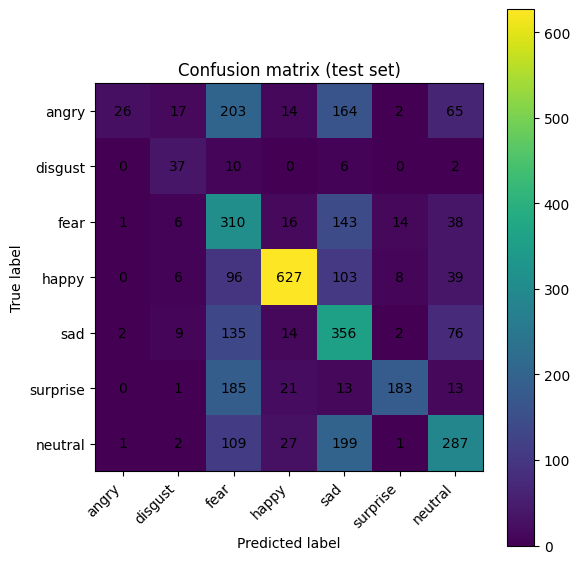

In [ ]:
# Plot confusion matrix
labels = [emotion_id_to_name[i] for i in range(num_classes)]

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, interpolation="nearest")
ax.figure.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix (test set)")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

Total misclassified examples: 1763


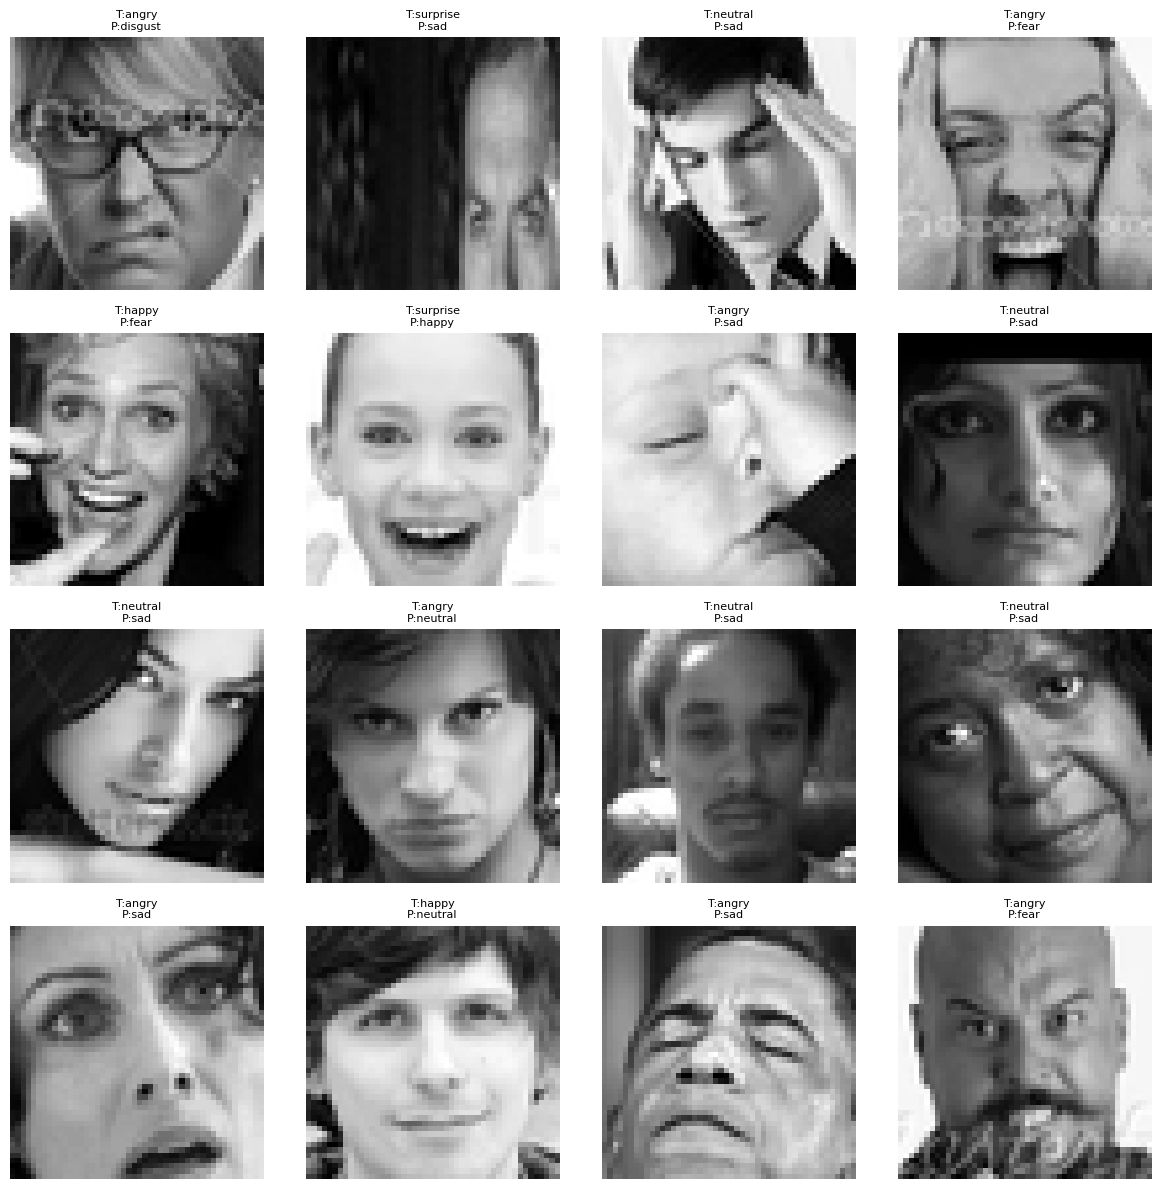

In [ ]:
mis_idx = np.where(y_test != y_pred)[0]
print(f"Total misclassified examples: {len(mis_idx)}")

num_show = min(16, len(mis_idx))
if num_show > 0:
    cols = 4
    rows = int(np.ceil(num_show / cols))
    plt.figure(figsize=(3 * cols, 3 * rows))

    for i in range(num_show):
        idx = mis_idx[i]
        img = X_test[idx].squeeze()
        true_label = emotion_id_to_name[y_test[idx]]
        pred_label = emotion_id_to_name[y_pred[idx]]

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"T:{true_label}\nP:{pred_label}", fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Computed BVI for 119 windows
BVI stats: min= 0.5687356321839081 max= 0.7862068965517243 mean= 0.6803052255384913


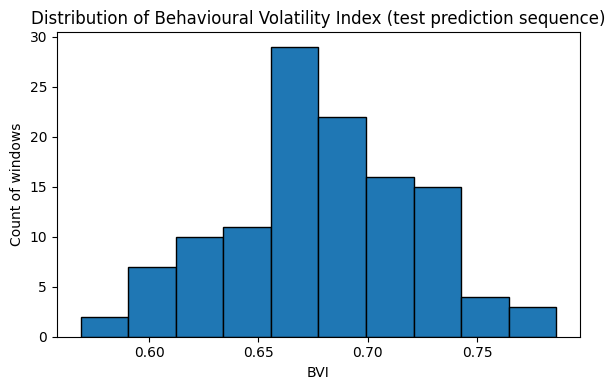

In [ ]:
negative_ids = {0, 1, 2, 4}  # angry, disgust, fear, sad

def compute_bvi_for_window(emotions_window):
    N = len(emotions_window)
    # emotion change rate
    changes = sum(1 for i in range(1, N) if emotions_window[i] != emotions_window[i-1])
    V = changes / max(N - 1, 1)
    # negative emotion ratio
    N_ratio = sum(1 for e in emotions_window if e in negative_ids) / N
    # dominance stability
    vals, counts = np.unique(emotions_window, return_counts=True)
    S = counts.max() / N
    return 0.4 * V + 0.4 * N_ratio + 0.2 * (1 - S)

window_size = 30
bvi_values = []
for start in range(0, len(y_pred) - window_size + 1, window_size):
    w = y_pred[start:start+window_size]
    bvi_values.append(compute_bvi_for_window(w))

bvi_values = np.array(bvi_values)
print("Computed BVI for", len(bvi_values), "windows")
print("BVI stats: min=", bvi_values.min(), "max=", bvi_values.max(), "mean=", bvi_values.mean())

plt.figure(figsize=(6,4))
plt.hist(bvi_values, bins=10, edgecolor="black")
plt.xlabel("BVI")
plt.ylabel("Count of windows")
plt.title("Distribution of Behavioural Volatility Index (test prediction sequence)")
plt.tight_layout()
plt.show()

In [ ]:
import cv2

CASCADE_PATH = "haarcascade_frontalface_default.xml"
if not os.path.exists(CASCADE_PATH):
    !wget -q https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml

face_cascade = cv2.CascadeClassifier(CASCADE_PATH)

EMOTION_LABELS = [emotion_id_to_name[i] for i in range(num_classes)]

def preprocess_face_from_image(image_path, target_size=(48, 48)):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("Could not read image:", image_path)
        return None

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    if len(faces) == 0:
        print("No face detected in:", image_path)
        return None

    x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
    face = gray[y:y+h, x:x+w]
    face_resized = cv2.resize(face, target_size)
    face_resized = face_resized.astype("float32") / 255.0
    face_resized = np.expand_dims(face_resized, axis=-1)
    face_resized = np.expand_dims(face_resized, axis=0)
    return face_resized

def predict_emotion(image_path):
    face_input = preprocess_face_from_image(image_path)
    if face_input is None:
        return

    preds = model.predict(face_input)[0]
    idx = int(np.argmax(preds))
    emotion = EMOTION_LABELS[idx]
    confidence = float(preds[idx])

    print("Image:", image_path)
    print(f"Predicted emotion: {emotion} (confidence: {confidence:.4f})")
    print("Class probabilities:")
    for label, p in zip(EMOTION_LABELS, preds):
        print(f"{label:10s}: {p:.4f}")